In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [2]:
#성별 / 연령대별 / 시간대별 / 요일별 / 월별  
import pandas as pd 
import csv

In [8]:
df4 = pd.read_csv('00_data/독립변수4_ 서울시 상권분석서비스(길단위인구-상권).csv',encoding='cp949')
df4.sample()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
21054,20232,A,골목상권,3110379,KT&G 북부지사,156178,76478,79699,23761,16635,...,21640,36179,18517,20994,20730,20559,20835,21276,24815,26972


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df4[df4['상권_구분_코드_명']=='골목상권'].head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
560,20262,A,골목상권,3111090,강일동주민센터,69926,33155,36771,16600,5476,...,8008,11288,9217,9940,9901,9917,9934,9894,10162,10180
561,20262,A,골목상권,3111089,상일여고(상일초등학교),801576,394782,406794,137717,79862,...,94353,131260,99110,117454,117454,117281,119295,118463,105398,106231
562,20262,A,골목상권,3111088,고덕동성당,267212,121894,145318,44368,27284,...,31418,48393,35197,37342,37453,38102,37675,38128,39337,39176
563,20262,A,골목상권,3111087,고덕중학교(고덕2동주민센터),251393,126874,124520,72936,22219,...,25916,32639,33221,37165,37800,38227,38121,37341,31086,31653
564,20262,A,골목상권,3111086,한영중고,441797,205634,236164,154278,35711,...,60818,69580,47237,65019,66771,64701,66332,66574,56326,56073


In [24]:
import requests, time
import pandas as pd
import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
load_dotenv()
KAKAO_KEY = os.getenv("KAKAO_REST_KEY")
HEADERS = {"Authorization": f"KakaoAK {KAKAO_KEY}"}

In [20]:
def geocode(addr):
    """한글 주소 → (위도, 경도). 주소 검색이 실패하면 키워드 검색으로 재시도"""
    for url in ["https://dapi.kakao.com/v2/local/search/address.json",
                "https://dapi.kakao.com/v2/local/search/keyword.json"]:
        r = requests.get(url, headers=HEADERS, params={"query": addr}, timeout=5)
        r.raise_for_status()
        docs = r.json()["documents"]
        if docs:
            return float(docs[0]["y"]), float(docs[0]["x"])   # 위도, 경도
    return None, None

# 데이터프레임에 적용 (같은 주소는 한 번만 호출)
df = pd.read_csv("00_data/서울시 상권분석서비스(상주인구-행정동).csv", encoding="cp949")
cache = {}
for a in df["행정동_코드_명"].dropna().unique():
    cache[a] = geocode(a)
    time.sleep(0.05)          # 호출 간격 조절
df["위도"] = df["행정동_코드_명"].map(lambda a: cache.get(a, (None, None))[0])
df["경도"] = df["행정동_코드_명"].map(lambda a: cache.get(a, (None, None))[1])

print(df[["행정동_코드_명", "위도", "경도"]])

     행정동_코드_명         위도          경도
0        둔촌2동  37.533348  127.141963
1        둔촌1동  37.523483  127.136691
2          길동  37.534486  127.142712
3        성내3동  37.526057  127.132899
4        성내2동  37.535995  127.128269
...       ...        ...         ...
9345      평창동  37.606392  126.968358
9346      부암동  37.592414  126.964061
9347      삼청동  37.584998  126.981758
9348      사직동  37.575422  126.966320
9349    청운효자동  37.584116  126.970650

[9350 rows x 3 columns]


In [22]:
df[["행정동_코드_명", "위도", "경도"]]

,기준_년분기_코드,행정동_코드,행정동_코드_명,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,연령대_30_상주인구_수,연령대_40_상주인구_수,...,여성연령대_20_상주인구_수,여성연령대_30_상주인구_수,여성연령대_40_상주인구_수,여성연령대_50_상주인구_수,여성연령대_60_이상_상주인구_수,총_가구_수,아파트_가구_수,비_아파트_가구_수,위도,경도
0,20262,11740700,둔촌2동,24228,11861,12367,3360,3110,3688,3495,...,1578,1814,1743,2043,3593,10426,0,10426,37.533348,127.141963
1,20262,11740690,둔촌1동,16,10,6,2,0,1,5,...,0,0,3,1,2,11,0,11,37.523483,127.136691
2,20262,11740685,길동,44395,21594,22801,4611,6297,7127,6419,...,3351,3490,3129,3671,6960,21799,0,21799,37.534486,127.142712
3,20262,11740660,성내3동,22433,10963,11470,2471,3268,3311,3357,...,1601,1608,1732,1983,3467,10645,0,10645,37.526057,127.132899
4,20262,11740650,성내2동,23452,11433,12019,1873,3921,4390,3062,...,2264,2121,1456,1698,3593,13395,0,13395,37.535995,127.128269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9345,20211,11110560,평창동,18390,8553,9837,2815,2450,2233,2767,...,1202,1201,1545,1792,2710,7519,0,7519,37.606392,126.968358
9346,20211,11110550,부암동,10015,4765,5250,1479,1340,1236,1628,...,651,648,873,941,1436,4389,0,4389,37.592414,126.964061
9347,20211,11110540,삼청동,2635,1271,1364,295,320,360,369,...,149,183,191,208,495,1340,0,1340,37.584998,126.981758
9348,20211,11110530,사직동,9524,4267,5257,1267,1238,1443,1476,...,670,824,817,862,1418,4758,0,4758,37.575422,126.966320


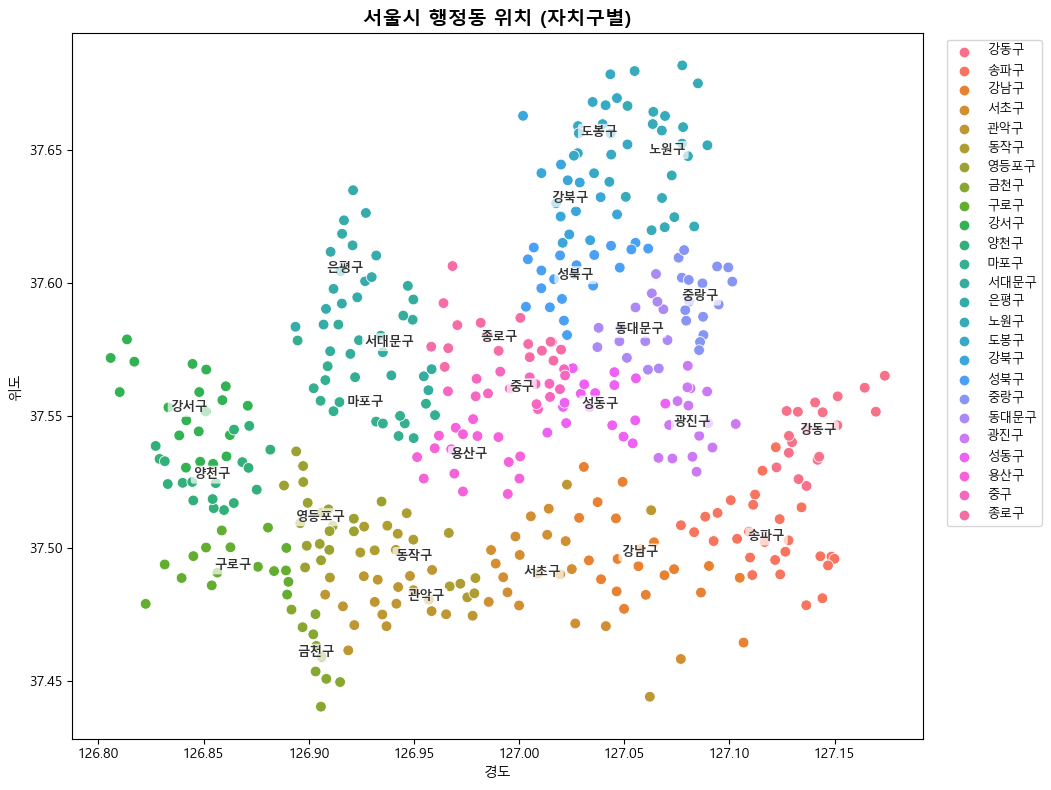

In [25]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트
plt.rc("font", family="Malgun Gothic" if platform.system() == "Windows" else "AppleGothic")
plt.rc("axes", unicode_minus=False)

# 1) 행정동 코드 앞 5자리 → 자치구
GU = {
    "11110": "종로구", "11140": "중구", "11170": "용산구", "11200": "성동구", "11215": "광진구",
    "11230": "동대문구", "11260": "중랑구", "11290": "성북구", "11305": "강북구", "11320": "도봉구",
    "11350": "노원구", "11380": "은평구", "11410": "서대문구", "11440": "마포구", "11470": "양천구",
    "11500": "강서구", "11530": "구로구", "11545": "금천구", "11560": "영등포구", "11590": "동작구",
    "11620": "관악구", "11650": "서초구", "11680": "강남구", "11710": "송파구", "11740": "강동구",
}
df["자치구"] = df["행정동_코드"].astype(str).str[:5].map(GU)

# 2) 최근 분기만 사용 (분기마다 좌표가 같아서 점이 겹치는 것 방지)
cur = df[df["기준_년분기_코드"] == df["기준_년분기_코드"].max()].dropna(subset=["위도", "경도"])

# 3) 자치구별 색상 산점도 (캡처와 같은 형태)
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=cur, x="경도", y="위도", hue="자치구",
                palette=sns.color_palette("husl", cur["자치구"].nunique()),
                s=60, edgecolor="white", linewidth=0.6, ax=ax)

# 자치구 이름을 중심에 표시 (색이 비슷한 구끼리 구분용)
for gu, g in cur.groupby("자치구"):
    ax.text(g["경도"].mean(), g["위도"].mean(), gu, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#333",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

ax.set_aspect(1 / np.cos(np.radians(37.55)))   # 위경도 비율 보정 (지도 모양 유지)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=9)
ax.set_title("서울시 행정동 위치 (자치구별)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

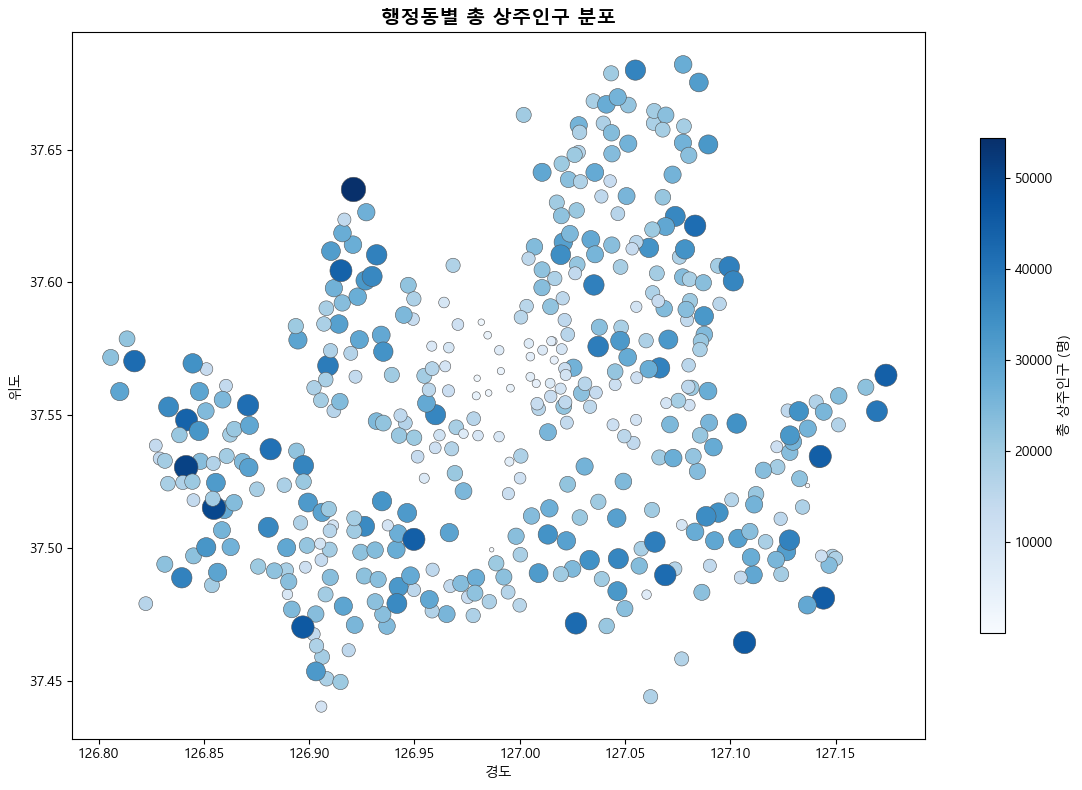

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(cur["경도"], cur["위도"], c=cur["총_상주인구_수"], cmap="Blues",
                s=cur["총_상주인구_수"] / cur["총_상주인구_수"].max() * 300 + 10,
                edgecolor="#555", linewidth=0.4)
fig.colorbar(sc, ax=ax, shrink=0.7, label="총 상주인구 (명)")
ax.set_aspect(1 / np.cos(np.radians(37.55)))
ax.set_xlabel("경도"); ax.set_ylabel("위도")
ax.set_title("행정동별 총 상주인구 분포", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()